### Project Overview – What This Model Does & How It Was Trained

This notebook documents the full training pipeline for our **YOLOv8 damage-detection model**. The model takes in images from the **Roboflow “wind-combined” (version 2)** dataset and outputs **bounding boxes and class labels** for different types of wind-asset damage (as defined in `data.yaml`). It is the same model architecture that will be used in the deployed Gradio app – the only thing the app needs is the **final weights file `best.pt`**.

---

#### 1. Data & Environment Setup

- We install all required packages (`roboflow`, `ultralytics`, `tensorflow`, `torch`, `keras`, `opencv`, etc.) and connect to Roboflow using an API key.  
- From the Roboflow workspace `"gayathry"` and project `"wind-combined"` (version 2), we download a YOLOv8-formatted dataset.  
- We verify the dataset structure via `data.yaml`, print the class names and total number of classes, and confirm that `train/`, `valid/`, and `test/` each contain matching **image** and **label (.txt)** files. Once everything checks out, we proceed to training.

---

#### 2. Baseline Model Training & Evaluation

- We start with a **pretrained YOLOv8n** model (`yolov8n.pt`) and train it for 30 epochs on the Roboflow dataset (image size 640, batch size 16).
- After training, we:
  - Evaluate the baseline model and log numeric metrics:
    - `mAP50-95`, `mAP50`, `mAP75`, **precision**, **recall**, **false alarm rate** (`1 - precision`), and **missed damage rate** (`1 - recall`).
  - Visualize performance using YOLO’s built-in plots:
    - `confusion_matrix.png`
    - `results.png`
  - Run predictions on the **test set** to visually inspect example detections and verify that bounding boxes and labels make sense.

This gives us a first benchmark of how well the model detects each damage class.

---

#### 3. Handling Class Imbalance via Oversampling

- We inspect the **class distribution** by reading all label files in `train/labels` and counting how many times each class appears.
- We identify **rare classes** (e.g., specific damage types with very few examples) and oversample them by:
  - Copying images/labels that contain these under-represented classes into an `aug/` directory.
  - Duplicating them multiple times (e.g., `duplicate_factor = 10`) with new filenames so that these classes appear more often in training.
- We then merge the oversampled data back into the main training set and **recount classes** to confirm the distribution is more balanced.

This step is crucial so the model doesn’t ignore rare but important damage types.

---

#### 4. Improved Model Training & Final Metrics

- After balancing the dataset, we upgrade to a **stronger YOLOv8 model** (`yolov8s.pt`) and retrain:
  - Higher resolution (`imgsz=800`),
  - Longer training (`epochs=60`),
  - Same overall setup (batch size 16, seed=42, cosine learning rate, early stopping via patience).
- We re-evaluate the improved model:
  - Again computing `mAP50-95`, `mAP50`, `mAP75`, precision, recall, false alarm rate, and missed damage rate.
  - Saving updated visual diagnostics: `runs/detect/train2/confusion_matrix.png` and `runs/detect/train2/results.png`.
- We run **test-set predictions** again to visually confirm that:
  - Rare classes are now being detected more frequently.
  - Bounding boxes and labels look consistent with expectations.

The best checkpoint from this improved training run is saved as: `runs/detect/train2/weights/best.pt`.

---

#### 5. Important for Deployment – Use `best.pt` as the Weights

For the client and for the Gradio app, the only file that matters from this training pipeline is the **final weights file**:

> **`best.pt` = the final production model weights**

This `best.pt` corresponds to the **improved YOLOv8s model trained after oversampling** and is the version we recommend for production use.

Anywhere you instantiate the model in code (including the Gradio interface), you should do:

    from ultralytics import YOLO

    model = YOLO("best.pt")  # <-- use this file

as long as `best.pt` is placed in the expected path (e.g., same directory as your app or as specified in your code).

You **do not** need to rerun the entire training pipeline in this notebook to use the model. That workflow is preserved here for transparency and reproducibility. For day-to-day usage and deployment, simply ensure that:

1. `best.pt` is available in your environment, and  
2. Your Gradio (or other) application loads `YOLO("best.pt")`.

This guarantees you are using the **final, fully trained model** documented in this notebook.


# Import Data From Roboflow

In [ ]:
# ============== CODE STARTS HERE! ==============
!pip install roboflow ultralytics
!pip install "sympy<1.13" # New versions, not compatible. So set it this.

from roboflow import Roboflow
rf = Roboflow(api_key="2seZOcizRn4vVMVEAlwn")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 76.8 MB/s eta 0:00:00
  Attempting uninstall: sympy
    Found existing installation: sympy 1.12.1
    Uninstalling sympy-1.12.1:
      Successfully uninstalled sympy-1.12.1
  Using cached sympy-1.12.1-py3-none-any.whl.metadata (12 kB)
Using cached sympy-1.12.1-py3-none-any.whl (5.7 MB)
  Attempting uninstall: sympy
    Found existing installation: sympy 1.14.0
    Uninstalling sympy-1.14.0:
      Successfully uninstalled sympy-1.14.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.9.0+cu126 requires sympy>=1.13.3, but you have sympy 1.12.1 which is incompatible.


# Import Libraries

In [ ]:
# Import necessary libraries
import os
import numpy as np
import pandas as pd
from pathlib import Path
import cv2
import sympy
import yaml, os, glob, random, shutil

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
import torch

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from PIL import Image
from ultralytics import YOLO
from IPython.display import Image, display
from collections import Counter
from collections import defaultdict

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


# Data Validation

In [ ]:
rf = Roboflow(api_key="2seZOcizRn4vVMVEAlwn")

project_main = rf.workspace("gayathry").project("wind-combined")
version_main = project_main.version(2)
dataset_main = version_main.download("yolov8")
root_main = Path(dataset_main.location)

project_extra = rf.workspace("windturbine-qopdj").project("wind-turbine-detect")
version_extra = project_extra.version(1)      # adjust if your extra project uses another version
dataset_extra = version_extra.download("yolov8")
root_extra = Path(dataset_extra.location)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to wind-combined-2 in yolov8:: 100%|██████████| 10238/10238 [00:01<00:00, 10040.94it/s]


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to wind-turbine-detect-1 in yolov8:: 100%|██████████| 6661/6661 [00:00<00:00, 8836.39it/s]


In [ ]:
# DATA VALIDATION:

# PART (1)
# - output damage types
# - output the number of images per folder
yaml_path = os.path.join(dataset_main.location, "data.yaml")

# Double confirming that data YAML reads fine
with open(yaml_path, "r") as f:
    configuration = yaml.safe_load(f)

print("Classes:", configuration.get("names"))
print("Total Classes:", configuration.get("nc"))

# ====================================
# PART (2)
# - checking the train images to .txt matching
root = dataset_main.location
for split in ["train", "valid", "test"]:
    i_patt = os.path.join(root, split, "images", "*.jpg")
    t_patt = os.path.join(root, split, "labels", "*.txt")
    imgs = glob.glob(i_patt)
    txts = glob.glob(t_patt)
    print(f"Split: {split}")
    print(f"Number of images: {len(imgs)}")
    print(f"Number of label/text files: {len(txts)}")

print("#===================")
print("All good to train!")

Classes: ['Drain hole impairment', 'Lightning Strike', 'OIL LEAKAGE', 'PU-tape', 'Paint', 'Surface Crack', 'dirt', 'le-erosion']
Total Classes: 8
Split: train
Number of images: 4278
Number of label/text files: 4278
Split: valid
Number of images: 537
Number of label/text files: 537
Split: test
Number of images: 298
Number of label/text files: 298
#===================
All good to train!


# Data Pipeline (finalized)

In [ ]:
# Read old (main) dataset YAML
with open(root_main / "data.yaml") as f:
    main_yaml = yaml.safe_load(f)
main_names = main_yaml["names"]
print("Main dataset classes:", main_names)

# Read extra dataset YAML
with open(root_extra / "data.yaml") as f:
    extra_yaml = yaml.safe_load(f)
extra_names = extra_yaml["names"]
print("Extra dataset classes:", extra_names)

# Helper: map extra class name -> canonical old class name (or None to drop)
def map_extra_name_to_main_name(name: str):
    n = name.strip().lower()
    if n in {"crack", "surface crack"}:
        return "Surface Crack"
    if n == "oil":
        return "OIL LEAKAGE"
    if n == "thunderstrike":
        return "Lightning Strike"
    # deformation, dirt, rust, etc. => ignored
    return None

Main dataset classes: ['Drain hole impairment', 'Lightning Strike', 'OIL LEAKAGE', 'PU-tape', 'Paint', 'Surface Crack', 'dirt', 'le-erosion']
Extra dataset classes: ['crack', 'deformation', 'dirt', 'oil', 'peeling', 'rust', 'thunderstrike']


In [ ]:
from pathlib import Path

def ensure_dir(path: Path):
    path.mkdir(parents=True, exist_ok=True)

# Make sure main dataset has the expected train/valid dirs
for split in ["train", "valid"]:
    ensure_dir(root_main / split / "images")
    ensure_dir(root_main / split / "labels")

# Function to process one split (train or valid) from extra → main
def merge_split_from_extra_to_main(split: str):
    extra_img_dir = root_extra / split / "images"
    extra_lbl_dir = root_extra / split / "labels"

    main_img_dir  = root_main / split / "images"
    main_lbl_dir  = root_main / split / "labels"

    if not extra_lbl_dir.exists():
        print(f"Split '{split}' not found in extra dataset, skipping.")
        return

    kept_files = 0
    skipped_files = 0

    for lbl_path in extra_lbl_dir.glob("*.txt"):
        with open(lbl_path) as f:
            lines = f.readlines()

        filtered_lines = []

        for line in lines:
            parts = line.strip().split()
            if not parts:
                continue
            old_cid = int(parts[0])
            if old_cid < 0 or old_cid >= len(extra_names):
                continue

            extra_name = extra_names[old_cid]
            mapped_main_name = map_extra_name_to_main_name(extra_name)

            # Skip labels we don't care about (deformation, dirt, rust, etc.)
            if mapped_main_name is None:
                continue

            # Find corresponding class index in the main dataset's names
            try:
                new_cid = main_names.index(mapped_main_name)
            except ValueError:
                # If the mapped class name isn't present in main_names, skip
                continue

            parts[0] = str(new_cid)  # overwrite class id
            filtered_lines.append(" ".join(parts) + "\n")

        # If no usable labels remain, skip this image entirely
        if not filtered_lines:
            skipped_files += 1
            continue

        # Find corresponding image in extra split
        stem = lbl_path.stem
        img_path = None
        for ext in [".jpg", ".jpeg", ".png"]:
            candidate = extra_img_dir / f"{stem}{ext}"
            if candidate.exists():
                img_path = candidate
                break

        if img_path is None:
            # No matching image file, skip
            skipped_files += 1
            continue

        # Copy image & remapped label into main dataset split
        dest_img = main_img_dir / img_path.name
        dest_lbl = main_lbl_dir / lbl_path.name

        # NOTE: if filenames overlap between datasets, this will overwrite.
        # If you suspect collisions, you can prefix with e.g. f"extra_{img_path.name}"
        shutil.copy(img_path, dest_img)

        with open(dest_lbl, "w") as f:
            f.writelines(filtered_lines)

        kept_files += 1

    print(f"[{split}] merged from extra -> main: kept {kept_files} files, skipped {skipped_files} files.")

# Merge both train and valid splits
merge_split_from_extra_to_main("train")
merge_split_from_extra_to_main("valid")

print("\nDone merging extra dataset into main dataset.")
print("You can now treat", root_main, "as the combined dataset root.")

root = root_main

[train] merged from extra -> main: kept 741 files, skipped 1710 files.
[valid] merged from extra -> main: kept 338 files, skipped 537 files.

Done merging extra dataset into main dataset.
You can now treat /content/wind-combined-2 as the combined dataset root.


# Data Setup

In [ ]:
# Setup for adapted model - now using combined dataset

from pathlib import Path
import yaml

# Use the merged dataset root created by Riya's merge code
# (root_main should exist already if you ran her merge block)
root = root_main

# Load the main YAML so we know the class names and paths
yaml_path = root / "data.yaml"
with open(yaml_path, "r") as f:
    data_yaml = yaml.safe_load(f)

print("Using dataset at:", root)
print("YAML file:", yaml_path)
print("Classes:", data_yaml["names"])

Using dataset at: /content/wind-combined-2
YAML file: /content/wind-combined-2/data.yaml
Classes: ['Drain hole impairment', 'Lightning Strike', 'OIL LEAKAGE', 'PU-tape', 'Paint', 'Surface Crack', 'dirt', 'le-erosion']


In [ ]:
# Class Counts in Combined Dataset

from collections import Counter

def count_labels_in_split(root_dir: Path, split: str, class_names):
    label_dir = root_dir / split / "labels"
    counts = Counter()

    if not label_dir.exists():
        print(f"No labels found for split '{split}' at {label_dir}")
        return

    for label_file in label_dir.glob("*.txt"):
        with open(label_file, "r") as f:
            for line in f:
                parts = line.strip().split()
                if not parts:
                    continue
                cls_id = int(parts[0])
                counts[cls_id] += 1

    total = sum(counts.values())
    print(f"\n=== {split.upper()} SPLIT ===")
    print(f"Total labeled objects: {total}")
    for cls_id, cnt in sorted(counts.items()):
        name = class_names[cls_id] if cls_id < len(class_names) else f"unknown_{cls_id}"
        pct = 100 * cnt / total if total > 0 else 0
        print(f"{cls_id:2d} | {name:20s} : {cnt:5d} ({pct:5.1f}%)")

# Use the merged dataset root and YAML from your setup cell
class_names = data_yaml["names"]
print("Classes:", class_names)

for split in ["train", "valid", "test"]:
    count_labels_in_split(root, split, class_names)

Classes: ['Drain hole impairment', 'Lightning Strike', 'OIL LEAKAGE', 'PU-tape', 'Paint', 'Surface Crack', 'dirt', 'le-erosion']

=== TRAIN SPLIT ===
Total labeled objects: 5589
 0 | Drain hole impairment :     6 (  0.1%)
 1 | Lightning Strike     :   312 (  5.6%)
 2 | OIL LEAKAGE          :   720 ( 12.9%)
 3 | PU-tape              :   280 (  5.0%)
 4 | Paint                :  1204 ( 21.5%)
 5 | Surface Crack        :   603 ( 10.8%)
 6 | dirt                 :   552 (  9.9%)
 7 | le-erosion           :  1912 ( 34.2%)

=== VALID SPLIT ===
Total labeled objects: 1129
 1 | Lightning Strike     :   235 ( 20.8%)
 2 | OIL LEAKAGE          :   203 ( 18.0%)
 3 | PU-tape              :     2 (  0.2%)
 4 | Paint                :   170 ( 15.1%)
 5 | Surface Crack        :   204 ( 18.1%)
 6 | dirt                 :    35 (  3.1%)
 7 | le-erosion           :   280 ( 24.8%)

=== TEST SPLIT ===
Total labeled objects: 302
 0 | Drain hole impairment :     1 (  0.3%)
 1 | Lightning Strike     :     3 ( 

## Model 4: Balanced Classes WITH Augmentation (For all classes except drain hole)

In [ ]:
from pathlib import Path
import random
from collections import defaultdict

random.seed(42)

root = root_main
labels_dir = root / "train" / "labels"
images_dir = root / "train" / "images"

# We still ignore class 0 (drain hole) for rebalancing, since it's tiny
balanced_classes = [1, 2, 3, 4, 5, 6, 7]

# === Step 1: map class -> list of image paths (not set; we want ordered lists) ===
class_to_images = {c: [] for c in balanced_classes}

for lbl in labels_dir.glob("*.txt"):
    img_path = images_dir / (lbl.stem + ".jpg")
    if not img_path.exists():
        continue

    with open(lbl, "r") as f:
        cls_ids = {int(line.split()[0]) for line in f if line.strip()}

    for c in cls_ids:
        if c in balanced_classes:
            class_to_images[c].append(str(img_path))

# Quick sanity print
for c in balanced_classes:
    print(f"Class {c}: {len(class_to_images[c])} images")

# === Step 2: choose target images per class ===

# Option A: full max (what you asked for)
max_images = max(len(imgs) for imgs in class_to_images.values() if len(imgs) > 0)

# If you ever want a cap like 3x minority, you could do it here:
# min_images = min(len(imgs) for imgs in class_to_images.values() if len(imgs) > 0)
# target_per_class = min(max_images, 3 * min_images)
# For now, use full max:
target_per_class = max_images

print(f"\nTarget images per class: {target_per_class} (max over classes)")

# === Step 3: oversample each class to target_per_class (with replacement) ===
oversampled_paths = []

for c in balanced_classes:
    imgs = class_to_images[c]
    n = len(imgs)

    if n == 0:
        print(f"Warning: class {c} has 0 images, skipping.")
        continue

    # number of full repeats + remainder
    reps = target_per_class // n
    rem  = target_per_class % n

    class_list = []

    # Full repeats
    for _ in range(reps):
        class_list.extend(imgs)

    # Remainder: sample without replacement if possible
    if rem > 0:
        if rem <= n:
            class_list.extend(random.sample(imgs, rem))
        else:
            # Fallback; shouldn't really happen since rem < n
            class_list.extend(random.choices(imgs, k=rem))

    oversampled_paths.extend(class_list)
    print(f"Class {c}: base {n}, oversampled to {len(class_list)} entries")

print(f"\nTotal oversampled entries (with repetition): {len(oversampled_paths)}")

# === Step 4: write oversampled train list ===
oversampled_list_path = root / "train_balanced_oversampled_max.txt"
with open(oversampled_list_path, "w") as f:
    for p in oversampled_paths:
        f.write(p + "\n")

print("Oversampled file written to:", oversampled_list_path)

Class 1: 231 images
Class 2: 528 images
Class 3: 280 images
Class 4: 1146 images
Class 5: 398 images
Class 6: 502 images
Class 7: 1902 images

Target images per class: 1902 (max over classes)
Class 1: base 231, oversampled to 1902 entries
Class 2: base 528, oversampled to 1902 entries
Class 3: base 280, oversampled to 1902 entries
Class 4: base 1146, oversampled to 1902 entries
Class 5: base 398, oversampled to 1902 entries
Class 6: base 502, oversampled to 1902 entries
Class 7: base 1902, oversampled to 1902 entries

Total oversampled entries (with repetition): 13314
Oversampled file written to: /content/wind-combined-2/train_balanced_oversampled_max.txt


In [ ]:
import yaml
from copy import deepcopy
from pathlib import Path

root = root_main
yaml_path = root / "data.yaml"

with open(yaml_path, "r") as f:
    base_yaml = yaml.safe_load(f)

data_oversampled = deepcopy(base_yaml)
data_oversampled["train"] = str(oversampled_list_path)  # list we just wrote

yaml_oversampled_path = root / "data_8class_oversampled_max.yaml"
with open(yaml_oversampled_path, "w") as f:
    yaml.safe_dump(data_oversampled, f)

print("Oversampled YAML written to:", yaml_oversampled_path)

Oversampled YAML written to: /content/wind-combined-2/data_8class_oversampled_max.yaml


In [ ]:
from ultralytics import YOLO

print("Training using oversampled YAML:", yaml_oversampled_path)

model_os = YOLO("yolov8n.pt")

results_os = model_os.train(
    data=str(yaml_oversampled_path),
    epochs=30,
    imgsz=640,
    batch=16,
    device=0,
    name="train_8class_oversampled_max"
)

print("Training complete! Model saved to:", model_os)

Training using oversampled YAML: /content/wind-combined-2/data_8class_oversampled_max.yaml
Ultralytics 8.3.231 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/wind-combined-2/data_8class_oversampled_max.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train_la

Loading oversampled model from: runs/detect/train_lauren_8class_oversampled_max/weights/best.pt
Using YAML: /content/wind-combined-2/data_8class_oversampled_max.yaml
Ultralytics 8.3.231 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
Model summary (fused): 72 layers, 3,007,208 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1197.6±293.9 MB/s, size: 34.9 KB)
val: Scanning /content/wind-combined-2/valid/labels.cache... 875 images, 7 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 875/875 1.3Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 543, len(boxes) = 1129. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 55/55 11.4it/s 4.8s
                   all        875 

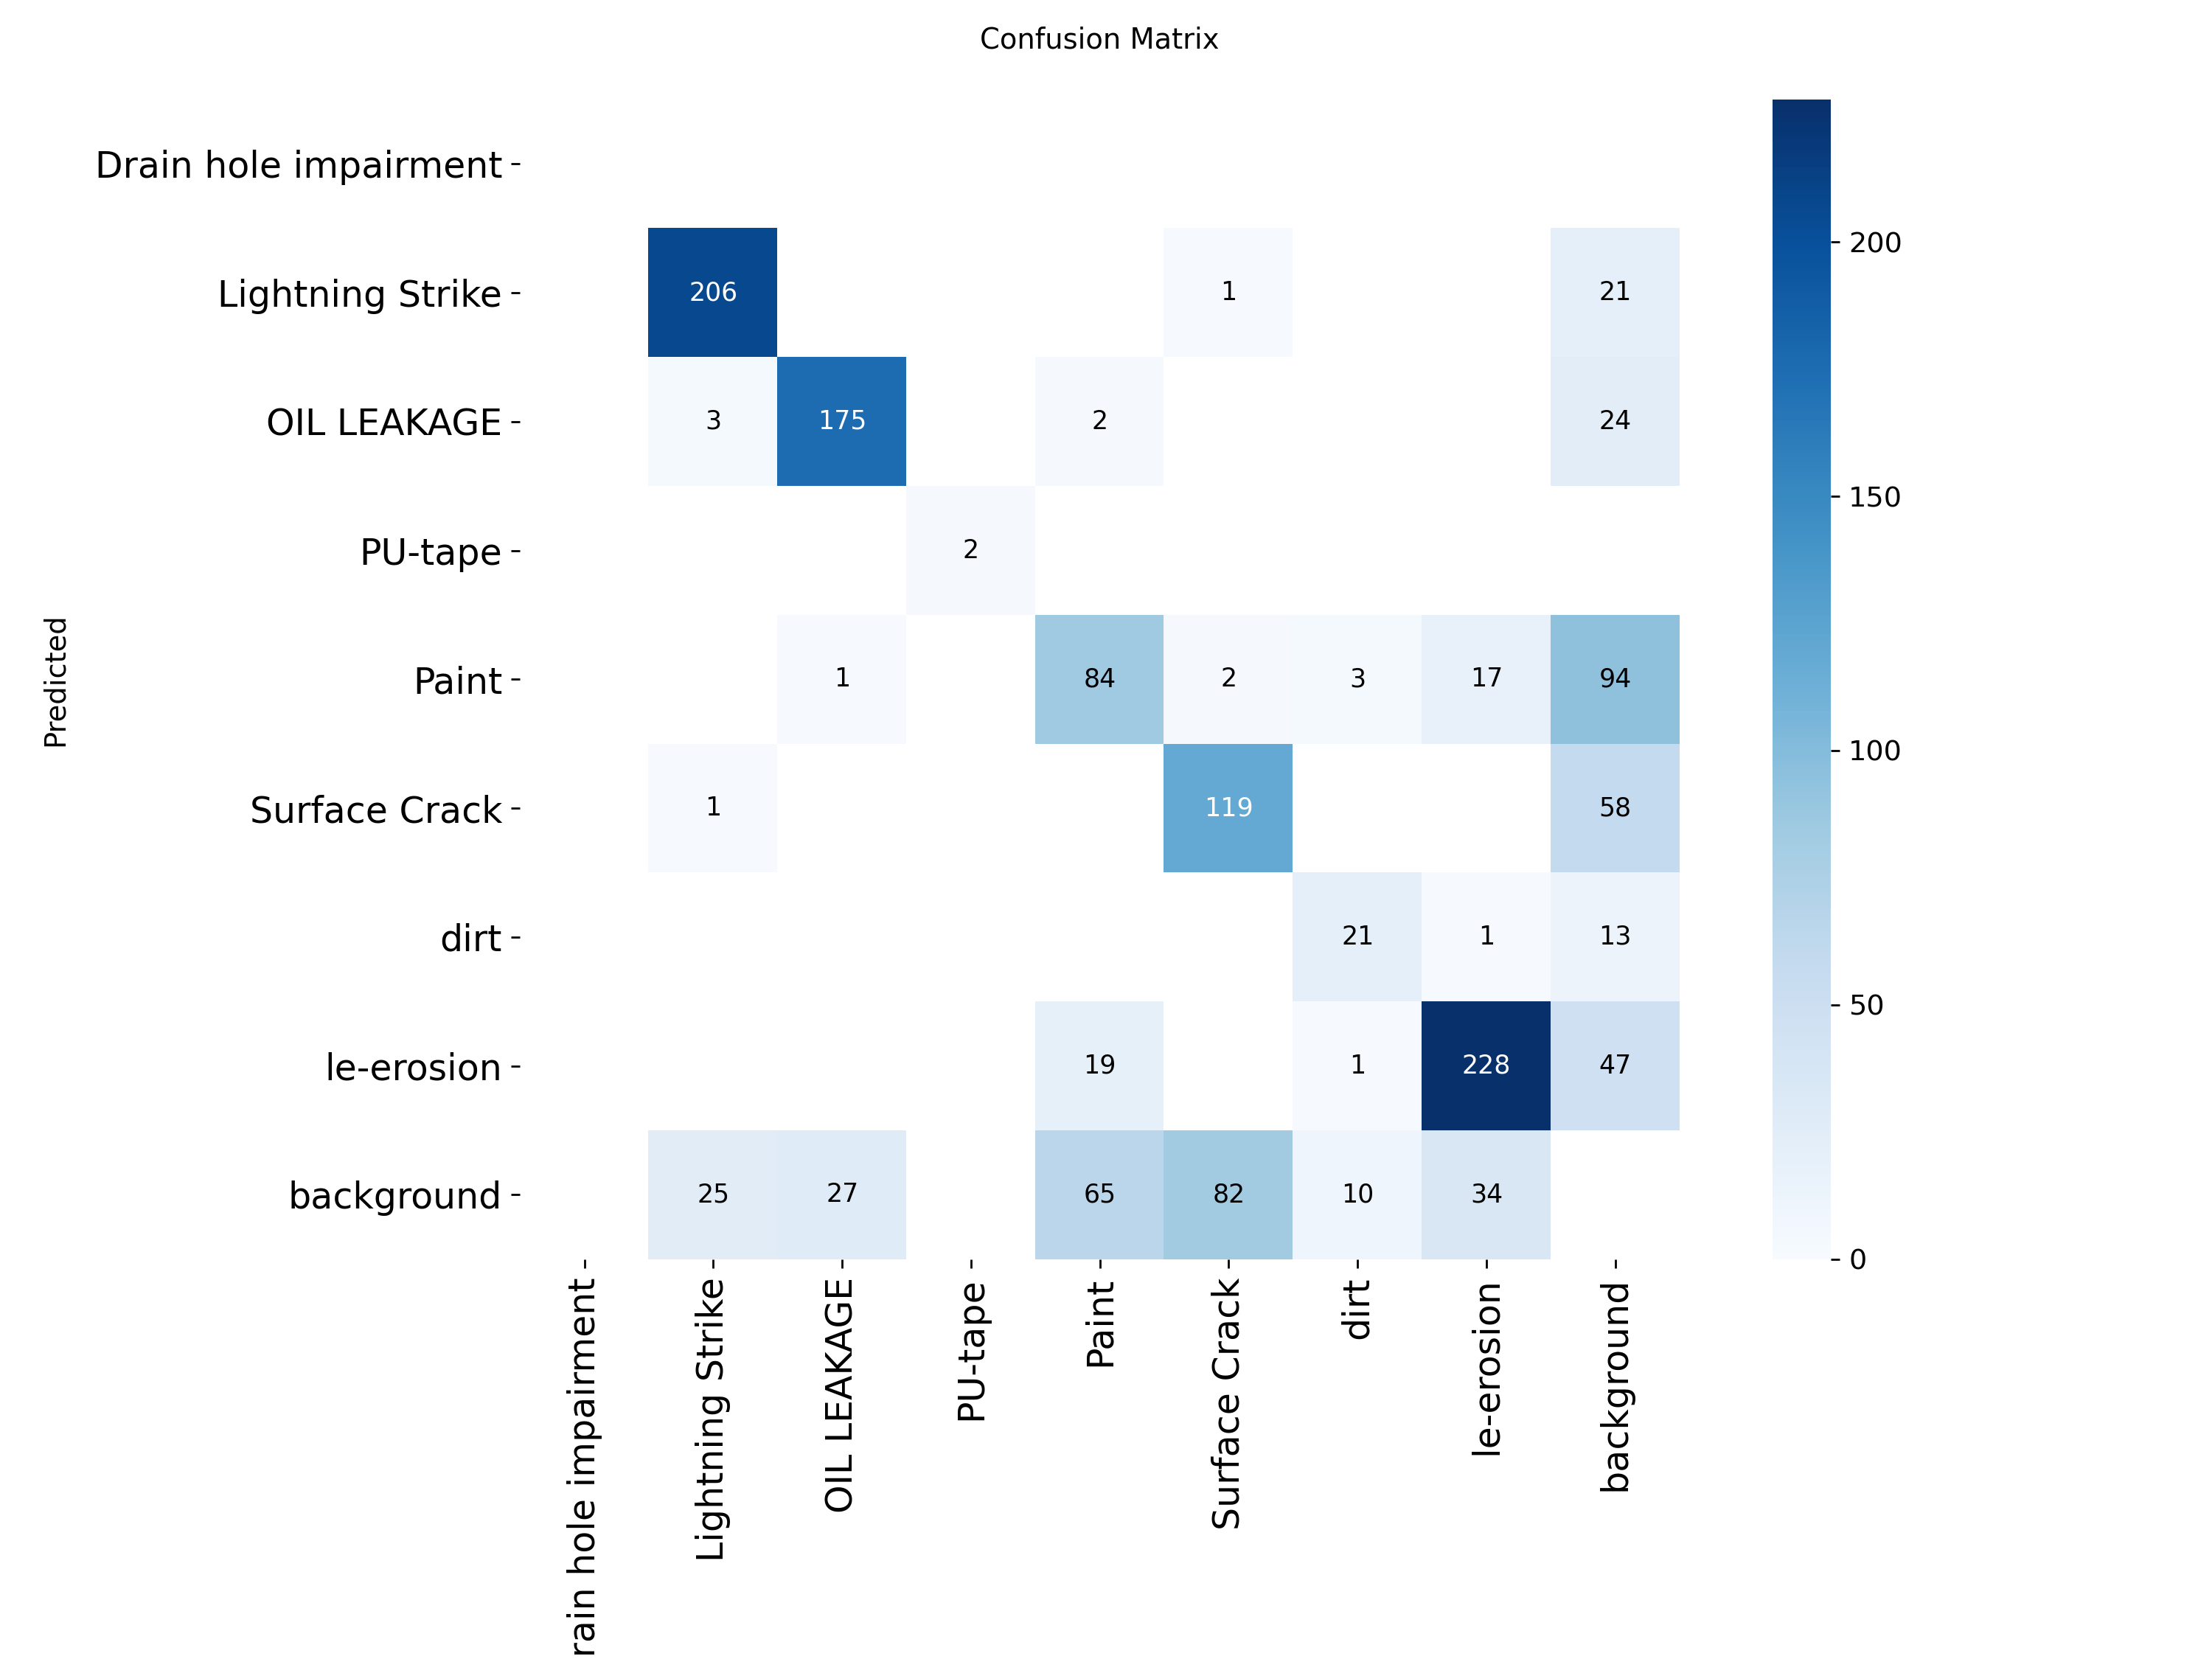

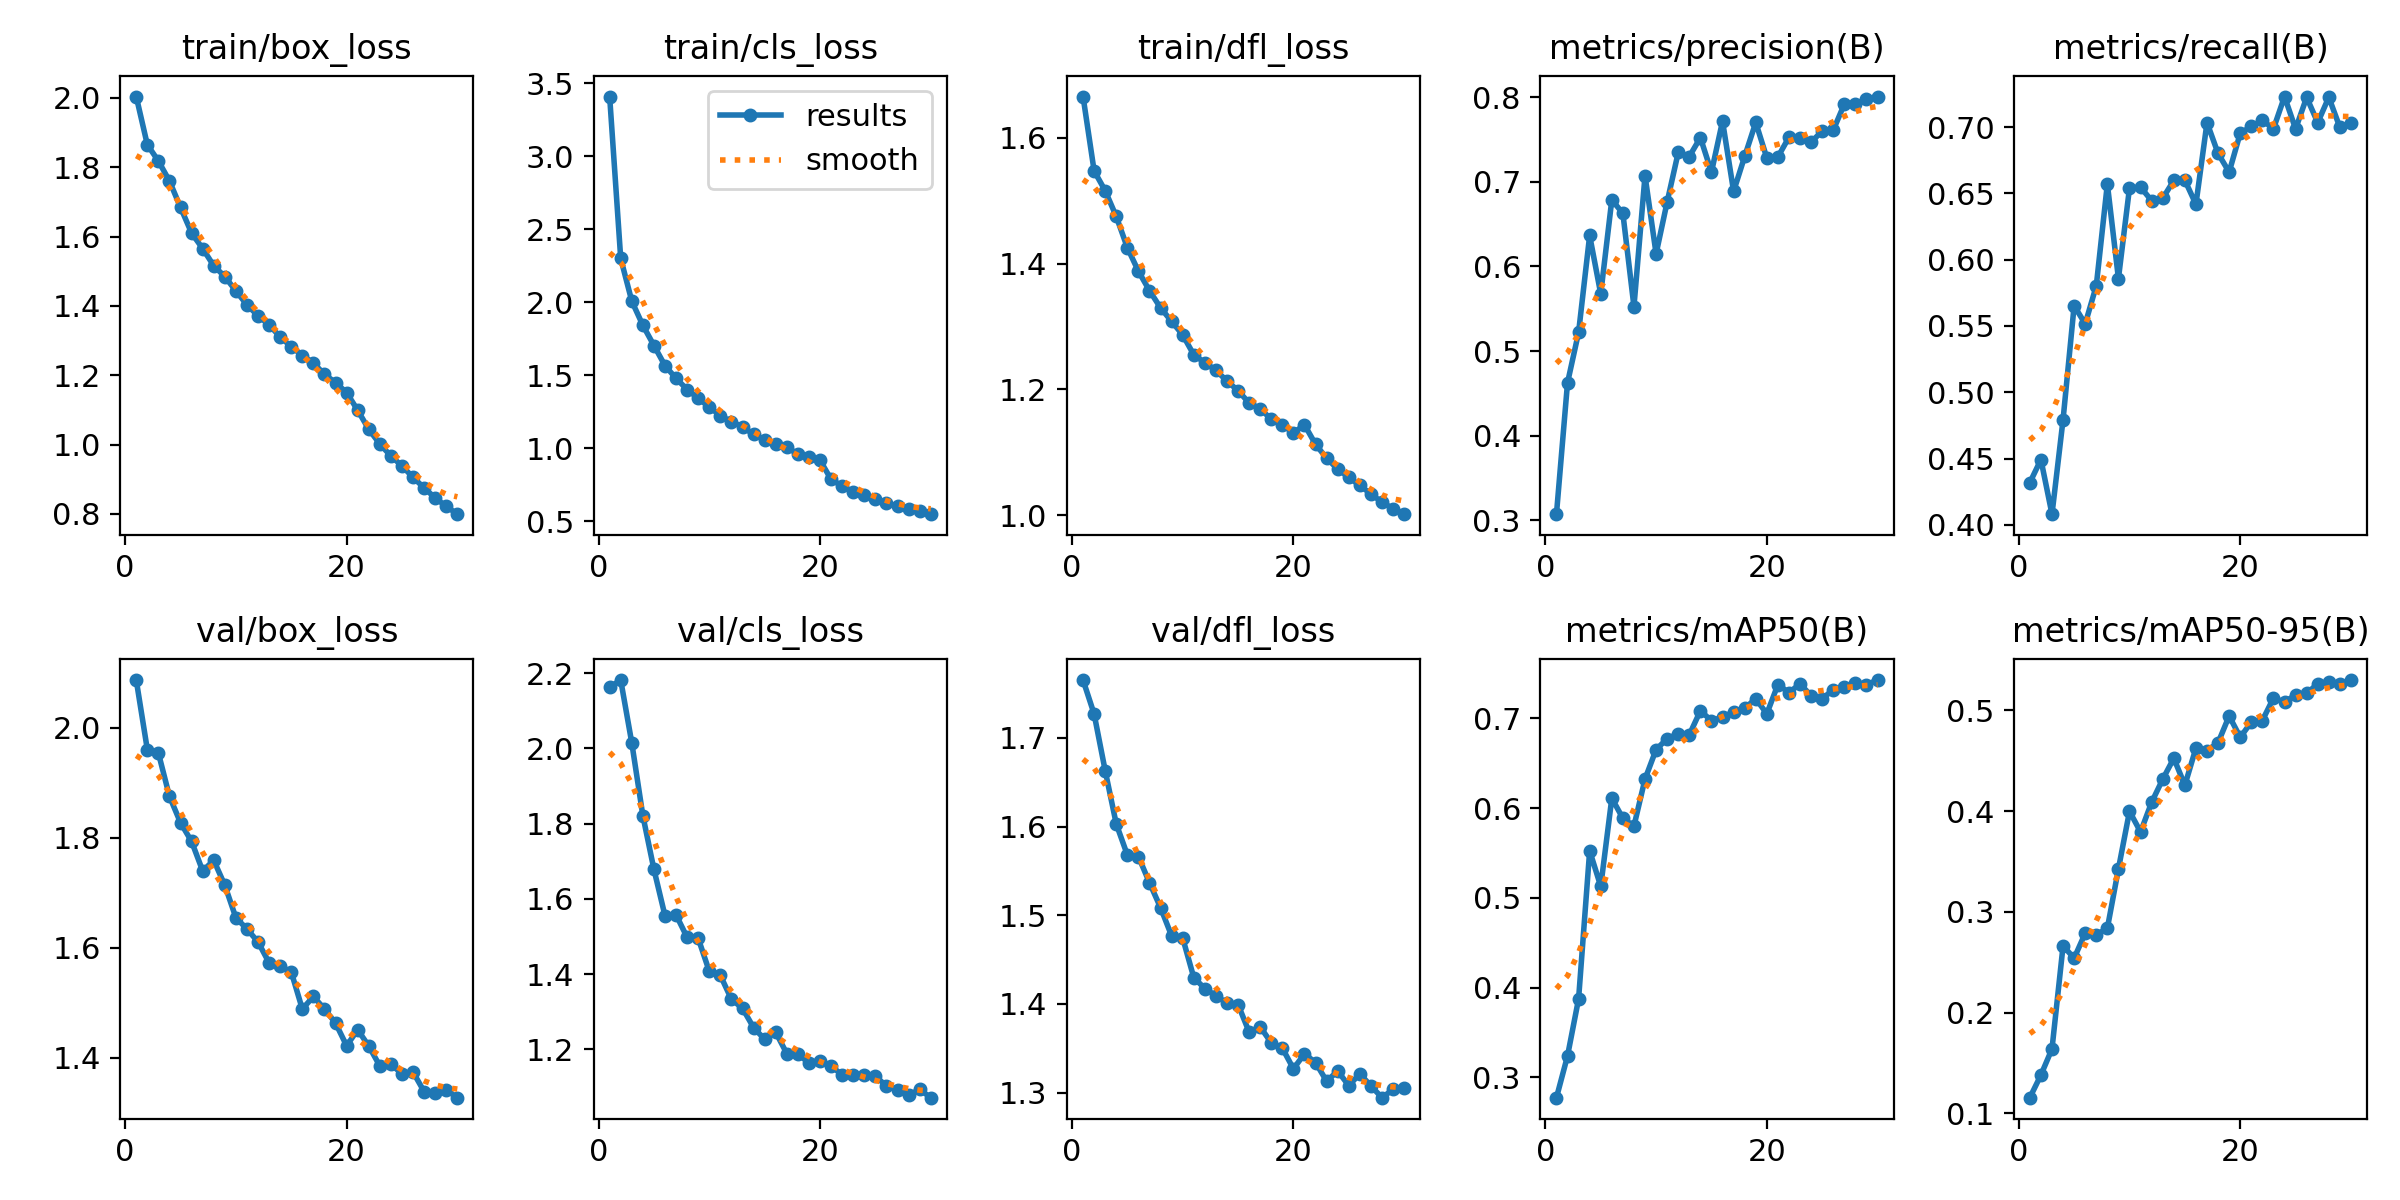

In [ ]:
# Code — Evaluation for 8-Class Oversampled + Augmented Model

from ultralytics import YOLO
from IPython.display import Image, display
from pathlib import Path

# === Adjust these if you changed names/paths ===
root = Path("/content/wind-combined-2")
yaml_oversampled_path = root / "data_8class_oversampled_max.yaml"

run_name = "train_8class_oversampled_max"
run_dir = Path("runs/detect") / run_name
weights_path = run_dir / "weights" / "best.pt"

print("Loading oversampled model from:", weights_path)
print("Using YAML:", yaml_oversampled_path)

# 1) Load best weights and run numeric eval
model_eval_os = YOLO(str(weights_path))
metrics_os = model_eval_os.val(data=str(yaml_oversampled_path))

print("\n=== 8-Class Oversampled + Augmented Model — Numeric Metrics ===")
print("mAP50-95:", metrics_os.box.map)
print("mAP50   :", metrics_os.box.map50)
print("mAP75   :", metrics_os.box.map75)
print("Precision:", metrics_os.box.p)
print("Recall   :", metrics_os.box.r)
print("False alarm rate   :", 1 - metrics_os.box.p)
print("Missed damage rate :", 1 - metrics_os.box.r)

# 2) Visual metrics: confusion matrix + training curves
print("\n=== Visual Metrics ===")
cm_path = run_dir / "confusion_matrix.png"
res_path = run_dir / "results.png"

if cm_path.exists():
    display(Image(filename=str(cm_path), width=600))
else:
    print("No confusion_matrix.png found at", cm_path)

if res_path.exists():
    display(Image(filename=str(res_path), width=600))
else:
    print("No results.png found at", res_path)

In [ ]:
# 3) Severity-based evaluation (severe vs not-severe)
# Severe: Lightning Strike (1), Surface Crack (5), le-erosion (7)
# Non-severe: all other classes (0, 2, 3, 4, 6)

cm = getattr(metrics_os, "confusion_matrix", None)

if cm is not None and getattr(cm, "matrix", None) is not None:
    cm_mat = cm.matrix  # shape: (nc, nc), rows = true, cols = pred

    severe_ids    = [1, 5, 7]
    nonsevere_ids = [0, 2, 3, 4, 6]

    severe_idx    = np.ix_(severe_ids, severe_ids)
    severe_to_non = np.ix_(severe_ids, nonsevere_ids)
    non_to_severe = np.ix_(nonsevere_ids, severe_ids)
    non_to_non    = np.ix_(nonsevere_ids, nonsevere_ids)

    # Collapse 8x8 → 2x2
    TP = float(cm_mat[severe_idx].sum())      # true severe → predicted severe
    FN = float(cm_mat[severe_to_non].sum())   # true severe → predicted non-severe
    FP = float(cm_mat[non_to_severe].sum())   # true non-severe → predicted severe
    TN = float(cm_mat[non_to_non].sum())      # true non-severe → predicted non-severe

    # Metrics
    precision_severe = TP / (TP + FP) if (TP + FP) > 0 else float("nan")
    recall_severe    = TP / (TP + FN) if (TP + FN) > 0 else float("nan")
    f1_severe        = (
        2 * precision_severe * recall_severe / (precision_severe + recall_severe)
        if (precision_severe + recall_severe) > 0 else float("nan")
    )

    print("\n=== Severe vs Not-Severe Confusion (Instance-Level) ===")
    print("               Pred Severe   Pred Not-Severe")
    print(f"True Severe    {int(TP):10d}   {int(FN):15d}")
    print(f"True Not-Sev   {int(FP):10d}   {int(TN):15d}")

    print("\n=== Severe-Class Metrics (treating 'severe' as positive) ===")
    print(f"Precision_severe : {precision_severe:.3f}")
    print(f"Recall_severe    : {recall_severe:.3f}")
    print(f"F1_severe        : {f1_severe:.3f}")
else:
    print("\nNo in-memory confusion matrix available on metrics_os.")


=== Severe vs Not-Severe Confusion (Instance-Level) ===
               Pred Severe   Pred Not-Severe
True Severe           556                19
True Not-Sev           21               288

=== Severe-Class Metrics (treating 'severe' as positive) ===
Precision_severe : 0.964
Recall_severe    : 0.967
F1_severe        : 0.965


# UI Code

In [ ]:
# Install Gradio. Must be done once per Colab runtime!!!!
!pip install --quiet gradio>=4.0.0

# 5-class names. BUT! It is actually in same order as data_5class.yaml
CLASS_NAMES = [
    "Lightning Strike",  # 0 for later reference
    "OIL LEAKAGE",       # 1 for later reference
    "PU-tape",           # 2 for later reference
    "Surface Crack",     # 3 for later reference
    "le-erosion"         # 4 for later reference
]

# ---------- Helper: automatically find best.pt ----------

def auto_find_best_pt(
    preferred_path="runs/detect/train_8class_oversampled_max/weights/best.pt",
    filename="best.pt",
    search_root="/content"  # for Colab
):
    """
    1. If preferred_path exists, use it.
    2. Otherwise, search recursively under search_root for filename.
    3. If multiple matches, use the first (shortest path).
    """

    # 1. Try the preferred path first
    if preferred_path is not None and os.path.exists(preferred_path):
        print(f"Using model at preferred path: {preferred_path}")
        return preferred_path

    # 2. Walk the directory tree and look for filename
    matches = []
    for root, dirs, files in os.walk(search_root):
        if filename in files:
            matches.append(os.path.join(root, filename))

    if not matches:
        raise FileNotFoundError(
            f"Could not find {filename} under {os.path.abspath(search_root)}.\n"
            f"Make sure you've uploaded it (e.g., to /content in Colab or mounted Drive)."
        )

    # 3. Pick one deterministically (shortest path)
    matches.sort(key=len)
    if len(matches) > 1:
        print("Multiple best.pt files found; using:", matches[0])
    else:
        print("Found model at:", matches[0])

    return matches[0]

# Find the model path in a robust way
MODEL_PATH = auto_find_best_pt(
    preferred_path="runs/detect/train_8class_oversampled_max/weights/best.pt",
    filename="best.pt",
    search_root="/content"  # use "." if not in Colab
)

# Load YOLO model
model = YOLO(MODEL_PATH)


# ---------- Prediction function ----------

def predict(image):
    conf_threshold = 0.25
    iou_threshold = 0.45

    # Run YOLO prediction
    results = model.predict(
        source=image,
        imgsz=640,
        conf=conf_threshold,
        iou=iou_threshold,
        verbose=False
    )
    res = results[0]

    # Annotated image
    annotated = res.plot()
    annotated = annotated[:, :, ::-1]  # BGR -> RGB

    # Count detections per class
    counts = {name: 0 for name in CLASS_NAMES}

    if res.boxes is not None and len(res.boxes) > 0:
        class_ids = res.boxes.cls.cpu().numpy().astype(int)
        for cid in class_ids:
            if 0 <= cid < len(CLASS_NAMES):
                counts[CLASS_NAMES[cid]] += 1

    # Provide summary text
    summary = "\n".join([f"{k}: {v}" for k, v in counts.items()])

    # Return only the two things the UI expects
    return annotated, summary


# ---------- Gradio Interface ----------

image_input = gr.Image(
    type="pil",
    label="Upload a wind turbine image"
)

annotated_output = gr.Image(
    label="Annotated Image"
)

text_output = gr.Textbox(
    label="Damage Counts (Summary)",
    lines=5
)

demo = gr.Interface(
    fn=predict,
    inputs=image_input,
    outputs=[annotated_output, text_output],
    title="Wind Turbine Damage Detector (YOLOv8)",
    description=(
        "Upload a wind turbine image. The model detects and counts: "
        "Lightning Strike, OIL LEAKAGE, PU-tape, Surface Crack, le-erosion."
    ),
    allow_flagging="never",
)

demo.launch(share=True)


Found model at: /content/best.pt


The `allow_flagging` parameter in `Interface` is deprecated. Use `flagging_mode` instead.


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0807a46a0f56fe4e80.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
